In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig

In [17]:
df = pd.read_csv('paths_finished.tsv', sep='\t', names=["hashedIpAddress","timestamp","durationInSec","path","rating"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51318 entries, 0 to 51317
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hashedIpAddress  51315 non-null  str    
 1   timestamp        51318 non-null  int64  
 2   durationInSec    51318 non-null  int64  
 3   path             51318 non-null  str    
 4   rating           28501 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.0 MB


In [18]:
df.head()

,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0


In [19]:
paths = df['path'].tolist()

In [20]:
def create_edges_from_paths(paths: list[str]) -> list[tuple[str, str]]:

    edges = []

    for path in paths:
        pages = path.split(";")

        stack = []
        previous_page = None

        for page in pages:

            if page == "<":
                if stack:
                    previous_page = stack.pop()

            else:
                if previous_page is not None:
                    edges.append((previous_page, page))

                stack.append(previous_page)
                previous_page = page

    return edges

In [21]:
def create_graph_from_paths(paths: list[str]) -> ig.Graph:
    edges = create_edges_from_paths(paths)
    edges = pd.DataFrame(edges, columns=["source", "target"])
    edges.drop_duplicates(inplace=True)
    return ig.Graph.DataFrame(edges, use_vids=False, directed=True)

14th_century;15th_century;16th_century;Pacific_Ocean;Atlantic_Ocean;Accra;Africa;Atlantic_slave_trade;African_slave_trade
14th_century;Europe;Africa;Atlantic_slave_trade;African_slave_trade
14th_century;Niger;Nigeria;British_Empire;Slavery;Africa;Atlantic_slave_trade;African_slave_trade


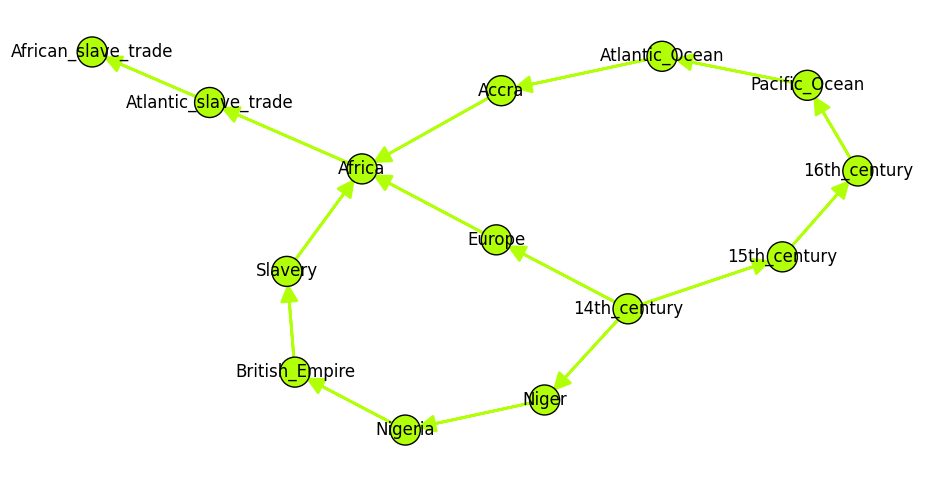

In [46]:
subset_paths = paths[0:3]
for path in subset_paths:
    print(path)
g = create_graph_from_paths(subset_paths)
fig, ax = plt.subplots(figsize=(12, 6))
ig.plot(g, target=ax,vertex_label=g.vs["name"], vertex_color="#B1FF08", edge_color="#B1FF08")

plt.show()

14th_century;Europe;<;England;<;Christianity;Anglicanism;United_States;Walt_Whitman;<;Poetry_of_the_United_States;<;<;<;French_Revolution;Age_of_Enlightenment;David_Hume;Philosophy;Fyodor_Dostoevsky;<;<;<;<;Constitutional_monarchy;Government;Anarchism;Henry_David_Thoreau
Aberdeen;Petroleum;Climate_change;Global_warming;Greenhouse_effect;Carbon_dioxide;Earth%27s_atmosphere;<;<;<;Kyoto_Protocol;<;Sea_level_rise;Effects_of_global_warming


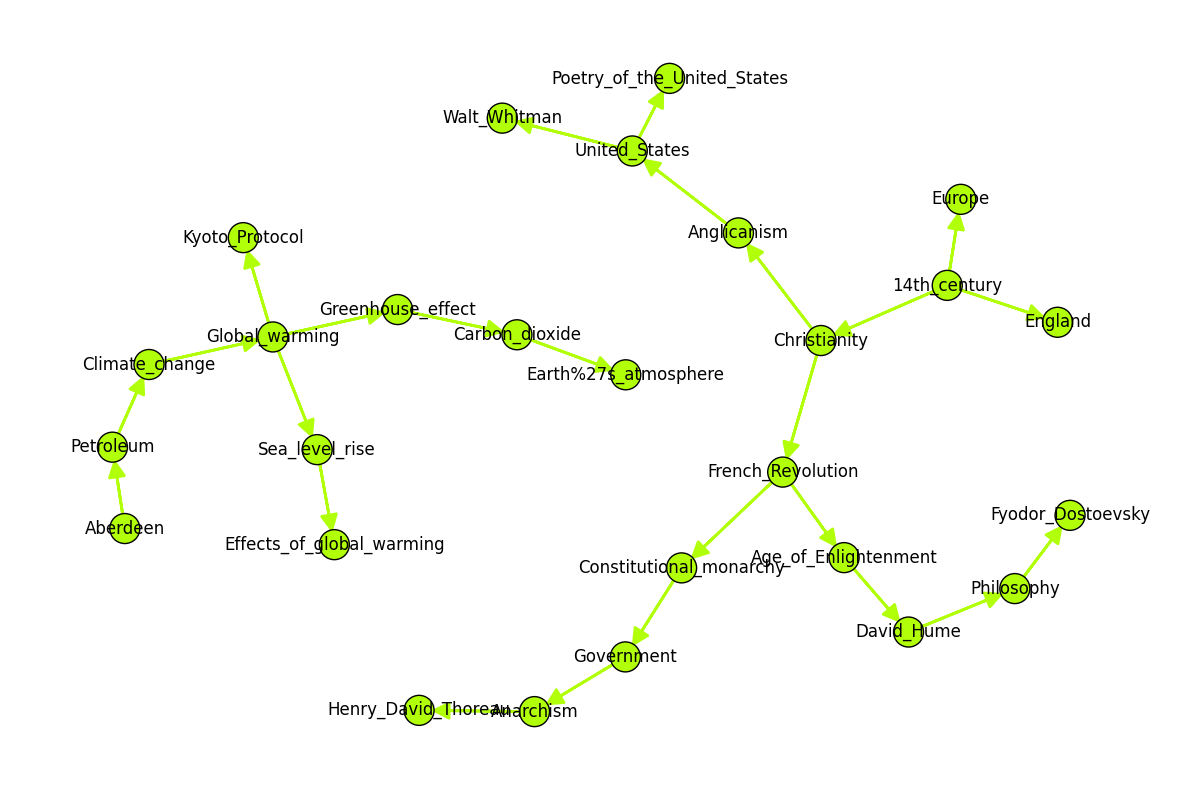

In [47]:
paths_with_back = [path for path in paths if "<;<;<" in path]
subset_paths = paths_with_back[0:2]
for path in subset_paths:
    print(path)
g = create_graph_from_paths(subset_paths)
fig, ax = plt.subplots(figsize=(15, 10))
ig.plot(g, target=ax,vertex_label=g.vs["name"], vertex_color="#B1FF08", edge_color="#B1FF08")
plt.show()

In [52]:
graph = create_graph_from_paths(paths)
adj_matrix = graph.get_adjacency().data 
adj_df = pd.DataFrame(adj_matrix, index=graph.vs["name"], columns=graph.vs["name"])
adj_df.head()

,14th_century,15th_century,16th_century,Pacific_Ocean,Atlantic_Ocean,Accra,Africa,Atlantic_slave_trade,African_slave_trade,Europe,...,Timken_1111,Tropical_Storm_Henri_%282003%29,Tropical_Storm_Larry_%282003%29,Tropical_Storm_Matthew_%282004%29,Uluru,United_States_Numbered_Highways,Valpara%C3%ADso,War_in_Somalia_%282006%E2%80%93present%29,Work_%28thermodynamics%29,Yagan
14th_century,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
15th_century,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
16th_century,0,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Pacific_Ocean,0,0,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Atlantic_Ocean,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [53]:
adj_df.to_csv("adjacency_matrix.csv")